In [185]:
# This project will be analyzing data from NYC Department of Parks and Recreation decennial Street Tree Census.
# The analysis will utilize the data found from OpenData.CityOfNewYork.US to analyze how NYC tree populations have changed over the last two NYC Street Tree Censuses, and how this data informs future management decisions.
# This data, obtained through initiatives such as Trees Count!, provides essential information about native and introduced tree species, particularly how their populations have changed over the last three decades.
# The information obtained in this analysis will allows us to conclude how well the NYC urban ecosystem is doing, what else can be done, and the effectiveness of initiatives such as Trees Count!

In [186]:
# We will first import our packages.

!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [187]:
# We will now download our datasets acquired from NYC.
# tc05 will stand for Tree Census 2005 and tc15 will stand for Tree Census 2015

tc05 = pd.read_csv("2005census.csv")
tc15 = pd.read_csv("2015census.csv")

/tmp/ipykernel_2944/1918229794.py:4: DtypeWarning: Columns (2,37,43) have mixed types. Specify dtype option on import or set low_memory=False.
  tc05 = pd.read_csv("2005census.csv")


In [188]:
# An error pops up regarding columns cen_year, borocode, and nta_name.
# We can specify their dtype option to ameliorate this issue.
# First, we will see what type the columns are.

ttype = tc05.dtypes 
ttype

OBJECTID          int64
cen_year          int64
tree_dbh         object
address          object
tree_loc         object
pit_type         object
soil_lvl         object
status           object
spc_latin        object
spc_common       object
vert_other       object
vert_pgrd        object
vert_tgrd        object
vert_wall        object
horz_blck        object
horz_grate       object
horz_plant       object
horz_other       object
sidw_crack       object
sidw_raise       object
wire_htap        object
wire_prime       object
wire_2nd         object
wire_other       object
inf_canopy       object
inf_guard        object
inf_wires        object
inf_paving       object
inf_outlet       object
inf_shoes        object
inf_lights       object
inf_other        object
trunk_dmg        object
zipcode           int64
zip_city         object
cb_num            int64
borocode          int64
boroname         object
cncldist          int64
st_assem          int64
st_senate         int64
nta             

In [189]:
# Now we have their dtypes, we can fully convert them so they are no longer mixed.

tc05['nta_name'] = tc05['nta_name'].astype(object)
tc05['cen_year'] = tc05['cen_year'].astype(np.int64)
tc05['borocode'] = tc05['borocode'].astype(np.int64)

In [190]:
# To view more of our data, we will expand the display limits of results.
pd.set_option('display.max_rows', 250)
pd.set_option('display.max_columns', None)

In [191]:
# Let's take a quick overview our datasets.

tc05

,OBJECTID,cen_year,tree_dbh,address,tree_loc,pit_type,soil_lvl,status,spc_latin,spc_common,vert_other,vert_pgrd,vert_tgrd,vert_wall,horz_blck,horz_grate,horz_plant,horz_other,sidw_crack,sidw_raise,wire_htap,wire_prime,wire_2nd,wire_other,inf_canopy,inf_guard,inf_wires,inf_paving,inf_outlet,inf_shoes,inf_lights,inf_other,trunk_dmg,zipcode,zip_city,cb_num,borocode,boroname,cncldist,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp,objectid_1,census tract,bin,bbl,Location 1
0,592373,2005,6,1139 57 STREET,Front,Sidewalk Pit,Level,Good,PYRUS CALLERYANA,"PEAR, CALLERY",No,No,No,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,NaN,11219,Brooklyn,312,3,Brooklyn,44,48,17,BK88,Borough Park,"3,021,600",New York,40.632653,-74.000245,"984,182","169,769",0,216.0,3140038.0,3.056890e+09,"(40.63265321, -74.00024499)"
1,592374,2005,6,2220 BERGEN AVENUE,Across,Sidewalk Pit,Level,Good,PLATANUS ACERIFOLIA,LONDON PLANETREE,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NaN,11234,Brooklyn,318,3,Brooklyn,46,59,19,BK45,Georgetown-Marine Park-Bergen Beach-Mill Basin,"3,070,600",New York,40.620084,-73.901453,"1,011,608","165,205",1,706.0,3238037.0,3.084440e+09,"(40.62008375, -73.9014528)"
2,592375,2005,13,2360 BERGEN AVENUE,Front,Continuous Pit,Level,Good,ACER PLATANOIDES CRIMSON KING,"MAPLE, NORWAY-CR KNG",No,No,No,No,No,No,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,No,Yes,No,No,No,Yes,Cavity,11234,Brooklyn,318,3,Brooklyn,46,59,19,BK45,Georgetown-Marine Park-Bergen Beach-Mill Basin,"3,070,600",New York,40.617996,-73.899111,"1,012,259","164,445",2,706.0,3238299.0,3.084530e+09,"(40.61799567, -73.89911096)"
3,592376,2005,13,2254 BERGEN AVENUE,Across,Sidewalk Pit,Level,Good,PLATANUS ACERIFOLIA,LONDON PLANETREE,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,11234,Brooklyn,318,3,Brooklyn,46,59,19,BK45,Georgetown-Marine Park-Bergen Beach-Mill Basin,"3,070,600",New York,40.619694,-73.901003,"1,011,733","165,063",3,706.0,3238045.0,3.084440e+09,"(40.6196936, -73.90100311)"
4,592377,2005,15,2332 BERGEN AVENUE,Across,Sidewalk Pit,Level,Good,PLATANUS ACERIFOLIA,LONDON PLANETREE,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NaN,11234,Brooklyn,318,3,Brooklyn,46,59,19,BK45,Georgetown-Marine Park-Bergen Beach-Mill Basin,"3,070,600",New York,40.618323,-73.899467,"1,012,160","164,564",4,706.0,3238294.0,3.084530e+09,"(40.61832261, -73.89946707)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592367,1184740,2005,9,62 LEWISTON STREET,Front,Lawn,Level,Good,PLATANUS ACERIFOLIA,LONDON PLANETREE,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,10314,Staten Island,502,5,5,50,63,24,SI24,Todt Hill-Emerson Hill-Heartland Village-Light...,NaN,New York,40.586260,-74.148797,"942,921","152,902","592,367",27704.0,5037776.0,5.023710e+09,"(40.58626041, -74.14879727)"
592368,1184741,2005,7,68 LEWISTON STREET,Front,Lawn,Level,Good,ACER SACCHARINUM,"MAPLE, SILVER",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,10314,Staten Island,502,5,5,50,63,24,SI24,Todt Hill-Emerson Hill-Heartland Village-Light...,NaN,New York,40.586090,-74.149013,"942,861","152,840","592,368",27704.0,5037778.0,5.023710e+09,"(40.58608995, -74.14901291)"
592369,1184742,2005,5,69 TRAVIS AVENUE,Side,Lawn,Level,Good,ACER PLATANOIDES CRIMSON KING,"MAPLE, NORWAY-CR KNG",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,10314,Staten Island,502,5,5,50,63,24,SI24,Todt Hill-Emerson Hill-Heartland Village-Light...,NaN,New York,40.585802,-74.149156,"942,821","152,735","592,369",27704.0,5037737.0,5.023710e+09,"(40.58580156, -74.14915628)"
592370,1184743,2005,9,69 TRAVIS AVENUE,Side,Lawn,Level,Good,ACER PLATANOIDES CRIMSON KING,"MAPLE, NORWAY-CR KNG",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No

In [192]:
# We can see that 592372 trees were recorded in the 2005 census.
# The mixed type error is no longer appearing for tc05 after the conversion.

tc15

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,steward,guards,sidewalk,user_type,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,address,postcode,zip_city,community board,borocode,borough,cncldist,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,NaN,NaN,NoDamage,TreesCount Staff,NaN,No,No,No,No,No,No,No,No,No,108-005 70 AVENUE,11375,Forest Hills,406,4,Queens,29,28,16,QN17,Forest Hills,"4,073,900",New York,40.723092,-73.844215,"1,027,431.148","202,756.7687",29.0,739,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,NaN,NaN,Damage,TreesCount Staff,Stones,Yes,No,No,No,No,No,No,No,No,147-074 7 AVENUE,11357,Whitestone,407,4,Queens,19,27,11,QN49,Whitestone,"4,097,300",New York,40.794111,-73.818679,"1,034,455.701","228,644.8374",19.0,973,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,1or2,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,390 MORGAN AVENUE,11211,Brooklyn,301,3,Brooklyn,34,50,18,BK90,East Williamsburg,"3,044,900",New York,40.717581,-73.936608,"1,001,822.831","200,716.8913",34.0,449,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,1027 GRAND STREET,11211,Brooklyn,301,3,Brooklyn,34,53,18,BK90,East Williamsburg,"3,044,900",New York,40.713537,-73.934456,"1,002,420.358","199,244.2531",34.0,449,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,NaN,NaN,Damage,Volunteer,Stones,Yes,No,No,No,No,No,No,No,No,603 6 STREET,11215,Brooklyn,306,3,Brooklyn,39,44,21,BK37,Park Slope-Gowanus,"3,016,500",New York,40.666778,-73.975979,"990,913.775","182,202.426",39.0,165,3025654.0,3.010850e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Good,Quercus palustris,pin oak,NaN,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,32 MARCY AVENUE,11211,Brooklyn,301,3,Brooklyn,34,53,18,BK73,North Side-South Side,"3,051,900",New York,40.713211,-73.954944,"996,740.686","199,121.6363",34.0,519,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Good,Cladrastis kentukea,Kentucky yellowwood,1or2,NaN,NoDamage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,67-035 SELFRIDGE STREET,11375,Forest Hills,406,4,Queens,29,28,15,QN17,Forest Hills,"4,070,700",New York,40.715194,-73.856650,"1,023,989.074","199,873.6475",29.0,707,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Good,Acer rubrum,red maple,NaN,NaN,Damage,Volunteer,NaN,No,No,No,No,No,No,No,No,No,130 BIDWELL AVENUE,10314,Staten Island,501,5,Staten Island,50,63,24,SI07,Westerleigh,"5,020,100",New York,40.620762,-74.136517,"946,351.4104","165,466.0763",50.0,201,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Good,Acer rubrum,red maple,NaN,NaN,NoDamage,TreesCount Staff,NaN,No,No,No,No,No,No,No,No,No,1985 ANTHONY AVENUE,10457,Bronx,205,2,Bronx,15,86,33,BX41,Mount Hope,"2,023,502",New York,40.850828,-73.903115,"1,011,053.646","249,271.9507",15.0,"23,502",2007757.0,2.028120e+09


In [193]:
# There were 683788 trees recorded in the 2015 census, a 91,416 increase from 2015!

tc05.shape


(592372, 54)

In [194]:
tc15.shape

(683788, 45)

In [195]:
tc05.columns

Index(['OBJECTID', 'cen_year', 'tree_dbh', 'address', 'tree_loc', 'pit_type',
       'soil_lvl', 'status', 'spc_latin', 'spc_common', 'vert_other',
       'vert_pgrd', 'vert_tgrd', 'vert_wall', 'horz_blck', 'horz_grate',
       'horz_plant', 'horz_other', 'sidw_crack', 'sidw_raise', 'wire_htap',
       'wire_prime', 'wire_2nd', 'wire_other', 'inf_canopy', 'inf_guard',
       'inf_wires', 'inf_paving', 'inf_outlet', 'inf_shoes', 'inf_lights',
       'inf_other', 'trunk_dmg', 'zipcode', 'zip_city', 'cb_num', 'borocode',
       'boroname', 'cncldist', 'st_assem', 'st_senate', 'nta', 'nta_name',
       'boro_ct', 'state', 'latitude', 'longitude', 'x_sp', 'y_sp',
       'objectid_1', 'census tract', 'bin', 'bbl', 'Location 1'],
      dtype='object')

In [196]:
tc15.columns

Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward',
       'guards', 'sidewalk', 'user_type', 'problems', 'root_stone',
       'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other',
       'brch_light', 'brch_shoe', 'brch_other', 'address', 'postcode',
       'zip_city', 'community board', 'borocode', 'borough', 'cncldist',
       'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state',
       'latitude', 'longitude', 'x_sp', 'y_sp', 'council district',
       'census tract', 'bin', 'bbl'],
      dtype='object')

In [197]:
# We can see there is a difference between the naming, amount, and focus between the two datasets' columns.
# To make it easier for a comparison we can clean up the data by isolating some columns and renaming similar columns between the datasets.
# We will be focusing on borough, species, and status. We will create new dataframes from our existing ones for easier analysis.

tc05s = tc05[['OBJECTID', 'tree_dbh', 'status', 'spc_common', 'boroname']]
tc05s

,OBJECTID,tree_dbh,status,spc_common,boroname
0,592373,6,Good,"PEAR, CALLERY",Brooklyn
1,592374,6,Good,LONDON PLANETREE,Brooklyn
2,592375,13,Good,"MAPLE, NORWAY-CR KNG",Brooklyn
3,592376,13,Good,LONDON PLANETREE,Brooklyn
4,592377,15,Good,LONDON PLANETREE,Brooklyn
...,...,...,...,...,...
592367,1184740,9,Good,LONDON PLANETREE,5
592368,1184741,7,Good,"MAPLE, SILVER",5
592369,1184742,5,Good,"MAPLE, NORWAY-CR KNG",5
592370,1184743,9,Good,"MAPLE, NORWAY-CR KNG",5


In [198]:
tc15s = tc15[['tree_id', 'tree_dbh', 'status', 'spc_common', 'borough']]
tc15s

,tree_id,tree_dbh,status,spc_common,borough
0,180683,3,Alive,red maple,Queens
1,200540,21,Alive,pin oak,Queens
2,204026,3,Alive,honeylocust,Brooklyn
3,204337,10,Alive,honeylocust,Brooklyn
4,189565,21,Alive,American linden,Brooklyn
...,...,...,...,...,...
683783,155433,25,Alive,pin oak,Brooklyn
683784,183795,7,Alive,Kentucky yellowwood,Queens
683785,166161,12,Alive,red maple,Staten Island
683786,184028,9,Alive,red maple,Bronx


In [199]:
# While the columns in both dataframes contain similar data, the names of the columns are different. We can change a few for easier analysis.

tc05s = tc05s.rename(columns={'OBJECTID': 'tree', 'tree_dbh': 'dbh', 'spc_common' : 'type', 'boroname' : 'borough'})
tc15s = tc15s.rename(columns={'tree_id': 'tree', 'tree_dbh': 'dbh', 'spc_common' : 'type'})

In [200]:
# Let's take a quick overview of all of our conversions. 

tc15s

,tree,dbh,status,type,borough
0,180683,3,Alive,red maple,Queens
1,200540,21,Alive,pin oak,Queens
2,204026,3,Alive,honeylocust,Brooklyn
3,204337,10,Alive,honeylocust,Brooklyn
4,189565,21,Alive,American linden,Brooklyn
...,...,...,...,...,...
683783,155433,25,Alive,pin oak,Brooklyn
683784,183795,7,Alive,Kentucky yellowwood,Queens
683785,166161,12,Alive,red maple,Staten Island
683786,184028,9,Alive,red maple,Bronx


In [201]:
tc05s

,tree,dbh,status,type,borough
0,592373,6,Good,"PEAR, CALLERY",Brooklyn
1,592374,6,Good,LONDON PLANETREE,Brooklyn
2,592375,13,Good,"MAPLE, NORWAY-CR KNG",Brooklyn
3,592376,13,Good,LONDON PLANETREE,Brooklyn
4,592377,15,Good,LONDON PLANETREE,Brooklyn
...,...,...,...,...,...
592367,1184740,9,Good,LONDON PLANETREE,5
592368,1184741,7,Good,"MAPLE, SILVER",5
592369,1184742,5,Good,"MAPLE, NORWAY-CR KNG",5
592370,1184743,9,Good,"MAPLE, NORWAY-CR KNG",5


In [202]:
dtype = tc05s.dtypes
dtype

tree        int64
dbh        object
status     object
type       object
borough    object
dtype: object

In [203]:
# Let's see the most populous tree species.
# First we will see how many species were recorded.

tc15s['type'].nunique()

132

In [204]:
tc05s['type'].nunique()

169

In [205]:
type05 = tc05s.groupby(['type'])['tree'].count().sort_values(ascending=False)
type05

type
LONDON PLANETREE             89529
MAPLE, NORWAY                74721
PEAR, CALLERY                63593
HONEYLOCUST                  52191
OAK, PIN                     43895
LINDEN, LITTLE LEAF          27664
ASH, GREEN                   20624
MAPLE, RED                   20254
MAPLE, SILVER                18666
UNKNOWN                      18362
GINKGO                       16256
ZELKOVA, JAPANESE            14625
OAK, NORTHERN RED            11076
CHERRY, OTHER                 9728
SWEETGUM                      8385
MAPLE, NORWAY-CR KNG          8134
LINDEN, AMERICAN              7229
JAPANESE PAGODA TREE          7067
LINDEN, SILVER                6013
ELM, AMERICAN                 5462
PLUM, PURPLELEAF              4793
Unknown Dead                  4612
MAPLE, SUGAR                  4478
BLACK LOCUST                  4349
MAPLE, SYCAMORE               4113
MAPLE, JAPANESE               2835
OAK, WILLOW                   2141
CHOKECHERRY, SHUBERT          2109
DOGWOOD, FLOWER

In [206]:
x = tc05s.count()
x

tree       592372
dbh        592372
status     592372
type       592372
borough    592372
dtype: int64

In [207]:
type15 = tc15s.groupby(['type'])['tree'].count().sort_values(ascending=False)
type15

type
London planetree          87014
honeylocust               64264
Callery pear              58931
pin oak                   53185
Norway maple              34189
littleleaf linden         29742
cherry                    29279
Japanese zelkova          29258
ginkgo                    21024
Sophora                   19338
red maple                 17246
green ash                 16251
American linden           13530
silver maple              12277
sweetgum                  10657
northern red oak           8400
silver linden              7995
American elm               7975
maple                      7080
purple-leaf plum           6879
swamp white oak            6598
crimson king maple         5923
Chinese elm                5345
'Schubert' chokecherry     4888
Japanese tree lilac        4568
eastern redbud             3801
golden raintree            3719
crab apple                 3527
Kentucky coffeetree        3364
willow oak                 3184
dawn redwood               3020
haw

In [208]:
# For simplicity, we will just focus on the top 5 species

species15 = tc15s.groupby(['type'])['tree'].count().sort_values(ascending=False).head()
species15

type
London planetree    87014
honeylocust         64264
Callery pear        58931
pin oak             53185
Norway maple        34189
Name: tree, dtype: int64

In [209]:
species05 = tc05s.groupby(['type'])['tree'].count().sort_values(ascending=False).head()
species05

type
LONDON PLANETREE    89529
MAPLE, NORWAY       74721
PEAR, CALLERY       63593
HONEYLOCUST         52191
OAK, PIN            43895
Name: tree, dtype: int64

In [210]:
# We can see that between the two censuses, the top 5 most populous trees are the same, with variation in their order.
# In regards to our analysis, and according to tree-map.nycgovparks.org, we have 3 introduced species (London planetree, Norway maple, and callery pear) and 2 native species (Honeylocust and pin oak) in our top 5 trees.
# We will also create an "Other" category for the rest of the trees for our visualization.

Other15 = (683788 - (87014 + 64264 + 58931 + 53185 + 34189))
Other15

386205

In [211]:
species15['Other'] = 386205
species15

type
London planetree     87014
honeylocust          64264
Callery pear         58931
pin oak              53185
Norway maple         34189
Other               386205
Name: tree, dtype: int64

In [212]:
Other05 = (592372 - (89529 + 74721 + 63593 + 52191 + 43895))
Other05

268443

In [213]:
species05['OTHER'] = 268443
species05

type
LONDON PLANETREE     89529
MAPLE, NORWAY        74721
PEAR, CALLERY        63593
HONEYLOCUST          52191
OAK, PIN             43895
OTHER               268443
Name: tree, dtype: int64

Text(0.5, 1.0, 'Tree Species of 2005 Street Tree Census as Percentages')

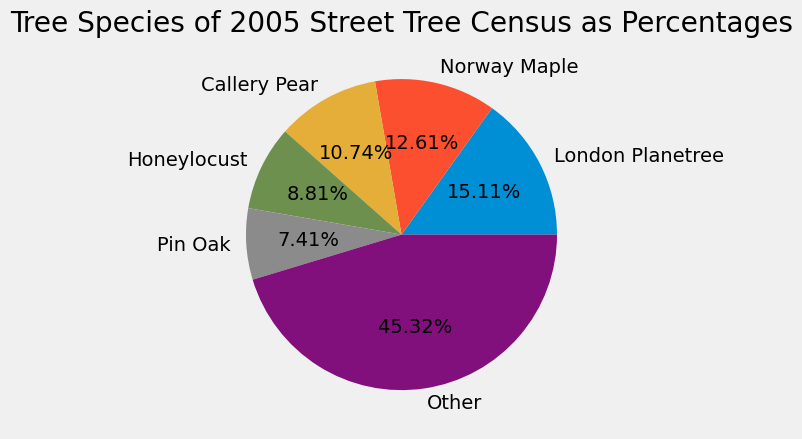

In [214]:
# Let's create pie charts to visualize the make up of the tree populations.
# We will use this as an opportunity to standardize the names of the tree species between the two.

labels = ["London Planetree", "Norway Maple", "Callery Pear", "Honeylocust", "Pin Oak", "Other"]
plt.pie(species05, labels=labels, autopct='%1.2f%%')
plt.title('Tree Species of 2005 Street Tree Census as Percentages')

Text(0.5, 1.0, 'Tree Species of 2015 Street Tree Census as Percentages')

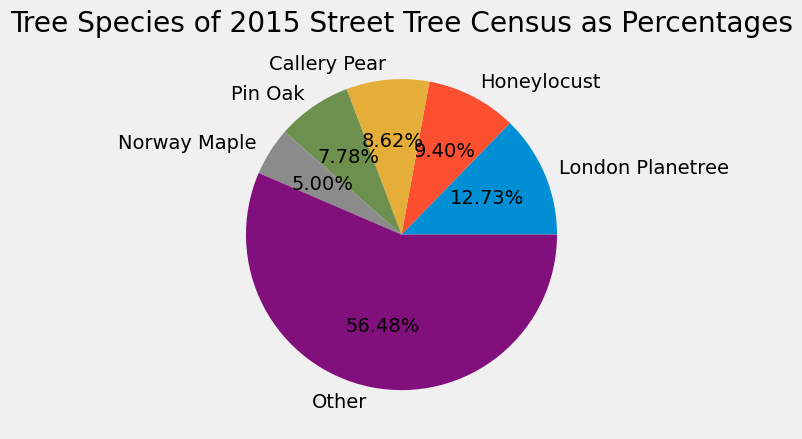

In [215]:
labels = ["London Planetree", "Honeylocust", "Callery Pear","Pin Oak","Norway Maple","Other"]
plt.pie(species15, labels=labels, autopct='%1.2f%%')
plt.title('Tree Species of 2015 Street Tree Census as Percentages')

In [216]:
# We can see from our charts that the percentages of all of our trees have gone down in the 2015 census. These charts only give us a percentage, but not the total amount of trees.
# It is possible that biodiversity has increased between the two censuses, leading to a larger percentage of "Other" in the 2015 census.
# Let's look at the number of trees by species.
# We will create a bar chart to illustrate the change between censuses for each species.
# For these visuals, we will exclude 'Other', and standardize the names of the species between the censuses.

species15d = species15[['London planetree', 'honeylocust', 'Callery pear', 'pin oak', 'Norway maple']]
species15d.rename({'London planetree' : 'London Planetree', 'honeylocust' : 'Honeylocust', 'Callery pear' : 'Callery Pear', 'pin oak' : 'Pin Oak', 'Norway maple' : 'Norway Maple'}, inplace=True)
species15d

type
London Planetree    87014
Honeylocust         64264
Callery Pear        58931
Pin Oak             53185
Norway Maple        34189
Name: tree, dtype: int64

In [217]:
species05d = species05[['LONDON PLANETREE', 'HONEYLOCUST', 'PEAR, CALLERY', 'OAK, PIN', 'MAPLE, NORWAY']]
species05d.rename({'LONDON PLANETREE' : 'London Planetree', 'HONEYLOCUST' : 'Honeylocust', 'PEAR, CALLERY' : 'Callery Pear', 'OAK, PIN' : 'Pin Oak', 'MAPLE, NORWAY' : 'Norway Maple'}, inplace=True)
species05d

type
London Planetree    89529
Honeylocust         52191
Callery Pear        63593
Pin Oak             43895
Norway Maple        74721
Name: tree, dtype: int64

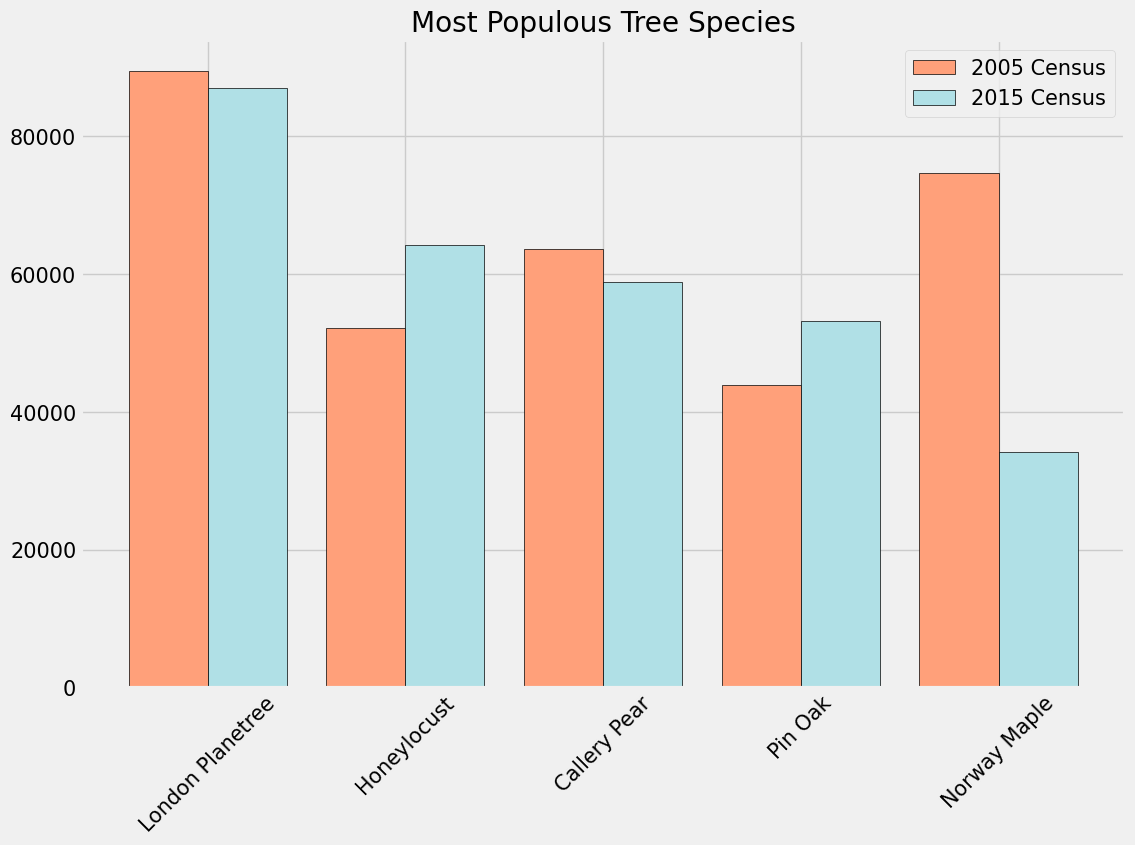

In [218]:
# And now our bar chart.

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12,8))
locs, labels = plt.xticks(fontsize=15); plt.yticks(fontsize=15)
plt.setp(labels, rotation=45)
plt.title('Most Populous Tree Species')
plt.bar(species05d.index,
        species05d, align='edge',
        width=-.4, ec='k', color='lightsalmon', alpha=1)
plt.bar(species15d.index,
        species15d, align='edge',
        width=.4, ec='k', color='powderblue', alpha=1)
plt.legend(['2005 Census', '2015 Census'], prop={'size': 15})

In [219]:
# This chart shows us that the native tree populations have risen and the introduced populations have reduced!
# The high drop in the Norway Maple population could be attributed to removal efforts and the dying of older individuals, according to Columbia University (http://www.columbia.edu/itc/cerc/danoff-burg/invasion_bio/inv_spp_summ/Acer_platanoides_2.htm).
# Let's count trees by borough.

byboro15 = tc15s.groupby(['borough'])['tree'].count()
byboro15

borough
Bronx             85203
Brooklyn         177293
Manhattan         65423
Queens           250551
Staten Island    105318
Name: tree, dtype: int64

In [220]:
byboro05 = tc05s.groupby(['borough'])['tree'].count()
byboro05

borough
5             84468
5             15233
Bronx         59925
Brooklyn     142852
Manhattan     49886
Queens       240008
Name: tree, dtype: int64

In [221]:
# Staten Island was split up into 2 separate values as "5" twice. Based on the 2015 results, we can assume that there are no
# repeat values between the two so we can combine them for our visualization. 

84468 + 15233

99701

In [222]:
# The two "5"s together are 99701. We will rewrite the dataframe with the new "Staten Island" value and drop the two "5"s.

byboro05["Staten Island"] = 99701
byboro05 = byboro05[['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']]
byboro05

borough
Bronx             59925
Brooklyn         142852
Manhattan         49886
Queens           240008
Staten Island     99701
Name: tree, dtype: int64

/tmp/ipykernel_2944/2487090213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=byboro05, palette = "YlGn")


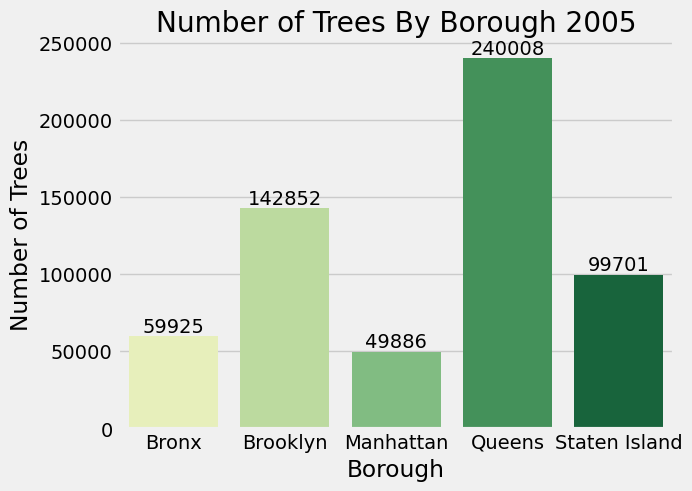

In [223]:
# Now we can create a visualization with a barplot.

ax = sns.barplot(data=byboro05, palette = "YlGn")
plt.xlabel('Borough')
plt.ylabel('Number of Trees')
plt.title('Number of Trees By Borough 2005')

for container in ax.containers:
    ax.bar_label(container)

/tmp/ipykernel_2944/3821733752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=byboro15, palette = "YlGn")


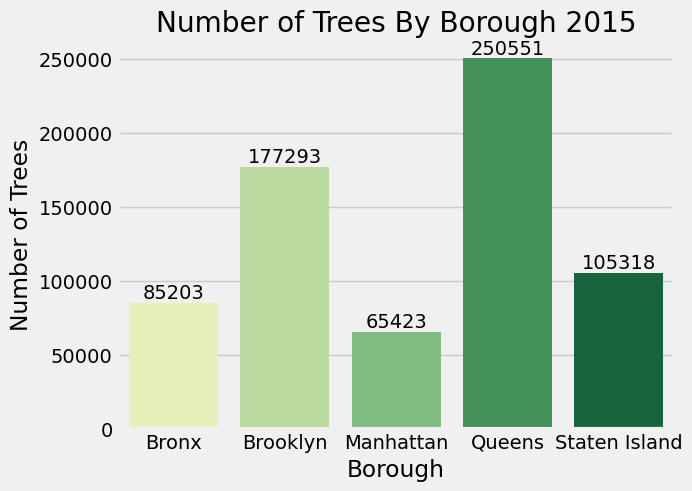

In [224]:
# And now for the 2015 census.

ax = sns.barplot(data=byboro15, palette = "YlGn")
plt.xlabel('Borough')
plt.ylabel('Number of Trees')
plt.title('Number of Trees By Borough 2015')

for container in ax.containers:
    ax.bar_label(container)

In [225]:
# Future Management Goals:
# Continue to make the census accessible to allow for the most amount of people. The 2025 census has already shown a 12.5% increase in participation from 2015. Data collection is also easier for volunteers (for example, only needing to measure diameter and a quick description of tree health), allowing for more trees to be censured and volunteers to be less intimidated by the work.
# Removing invasive species will allow for healthier ecosystems and promote the growth of native species. As introduced species - that were planted before regulations banned their introduction - begin to die off, it is a great opportunity to plant more native species. Tracking these populations with the NYC Street Tree Census provides essential data to create realistic management goals.
# In conclusion, while urban planners of the past may have not understood the full effect of planting non-native city trees, there is plenty of information today to prove the harm they cause. Trees Count! has a secondary effect of engaging the public in this process and spreading awareness of the harm of non-native species.
# It was exciting to see how there has been such a positive change in native vs non-native species. As someone who routinely monitors these species it can feel overwhelming to see an over-representation of non-natives. I expect to see a much higher number of volunteers in the 2025 Trees Count! compared to previous counts, confirmed by the growth of volunteers between each count.
